In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

# file = pd.read_json("./made_up_stats.json")
df = pd.read_csv('./sim_data.csv')

df['parsed_json'] = df['JSON Brut'].apply(json.loads)

unpacked_df = pd.json_normalize(df['parsed_json'])

df = pd.concat([df.drop(columns=['JSON Brut', 'parsed_json']), unpacked_df], axis=1)
df

,Data,Cod,Scor Total,Info,Mate,Timp,id_participant,timp_folosit,scor_total,scor_info,scor_mate,detalii_info,detalii_mate
0,21.03.2026 11:29:06,ST990594,1,0,1,32s,ST990594,32s,1,0,1,"[{'problem': 1, 'answer': None, 'correct': 'd'...","[{'problem': 1, 'answer': None, 'correct': 'b'..."
1,21.03.2026 11:53:30,ST686,0,0,0,2min 29s,ST686,2min 29s,0,0,0,"[{'problem': 1, 'answer': None, 'correct': 'd'...","[{'problem': 1, 'answer': None, 'correct': 'b'..."
2,21.03.2026 11:54:59,ST946682,1,0,1,1min 26s,ST946682,1min 26s,1,0,1,"[{'problem': 1, 'answer': None, 'correct': 'd'...","[{'problem': 1, 'answer': None, 'correct': 'b'..."
3,21.03.2026 13:56:49,ST481831,1,0,1,4min 45s,ST481831,4min 45s,1,0,1,"[{'problem': 1, 'answer': None, 'correct': 'd'...","[{'problem': 1, 'answer': None, 'correct': 'b'..."
4,21.03.2026 14:02:44,ST965560,19,10,9,1min 43s,ST965560,1min 43s,19,10,9,"[{'problem': 1, 'answer': 'd', 'correct': 'd'}...","[{'problem': 1, 'answer': 'b', 'correct': 'b'}..."
5,21.03.2026 14:04:19,ST106490,20,10,10,1min 1s,ST106490,1min 1s,20,10,10,"[{'problem': 1, 'answer': 'd', 'correct': 'd'}...","[{'problem': 1, 'answer': 'b', 'correct': 'b'}..."


In [201]:
df['timp_folosit_minutes'] = pd.to_timedelta(df['timp_folosit'])
df['timp_folosit_minutes'] = df['timp_folosit_minutes'].dt.total_seconds() / 60
df['timp_folosit_minutes'] = df['timp_folosit_minutes'].round(0)

column_to_move = df.pop('timp_folosit_minutes')
df.insert(2, 'timp_folosit_minutes', column_to_move)

# New column names
info_names = [f"problema_{i}_info" for i in range(1, 11)]
mate_names = [f"problema_{i}_mate" for i in range(1, 11)]

# Populate math answers
mate_df = df.explode('detalii_mate')
expanded_mate = mate_df['detalii_mate'].apply(pd.Series)
correct_mate = expanded_mate['correct']
correct_mate = correct_mate.rename('mate-answer-key')

reshaped_mate = expanded_mate['answer'].values.reshape(-1, 10)
mate_ans = pd.DataFrame(reshaped_mate, columns=mate_names)

# Populate info answers
info_df = df.explode('detalii_info')
expanded_info = info_df['detalii_info'].apply(pd.Series)
correct_info = expanded_info['correct']
correct_info = correct_info.rename('info-answer-key')

reshaped_info = expanded_info['answer'].values.reshape(-1, 10)
info_ans = pd.DataFrame(reshaped_info, columns=info_names)

# Add results together
cleaned_df = df.drop(columns=['detalii_info', 'detalii_mate'])

cleaned_df = cleaned_df.reset_index(drop=True)
correct_info = correct_info.reset_index(drop=True)
correct_mate = correct_mate.reset_index(drop=True)
mate_ans = mate_ans.reset_index(drop=True)
info_ans = info_ans.reset_index(drop=True)

mate_answer_key = pd.Series(correct_mate.iloc[:10].values)
info_answer_key = pd.Series(correct_info.iloc[:10].values)

final_barem = pd.DataFrame({
    'Mate_Answers': mate_answer_key,
    'Info_Answers': info_answer_key
})

final_df = pd.concat([cleaned_df, mate_ans, info_ans], axis=1)
final_df


,Data,Cod,timp_folosit_minutes,Scor Total,Info,Mate,Timp,id_participant,timp_folosit,scor_total,...,problema_1_info,problema_2_info,problema_3_info,problema_4_info,problema_5_info,problema_6_info,problema_7_info,problema_8_info,problema_9_info,problema_10_info
0,21.03.2026 11:29:06,ST990594,1.0,1,0,1,32s,ST990594,32s,1,...,None,None,None,None,None,None,None,None,None,None
1,21.03.2026 11:53:30,ST686,2.0,0,0,0,2min 29s,ST686,2min 29s,0,...,None,None,None,None,None,None,None,None,None,None
2,21.03.2026 11:54:59,ST946682,1.0,1,0,1,1min 26s,ST946682,1min 26s,1,...,None,None,None,None,None,None,None,None,None,None
3,21.03.2026 13:56:49,ST481831,5.0,1,0,1,4min 45s,ST481831,4min 45s,1,...,None,None,None,None,None,None,None,None,None,None
4,21.03.2026 14:02:44,ST965560,2.0,19,10,9,1min 43s,ST965560,1min 43s,19,...,d,d,b,c,b,d,c,b,e,d
5,21.03.2026 14:04:19,ST106490,1.0,20,10,10,1min 1s,ST106490,1min 1s,20,...,d,d,b,c,b,d,c,b,e,d


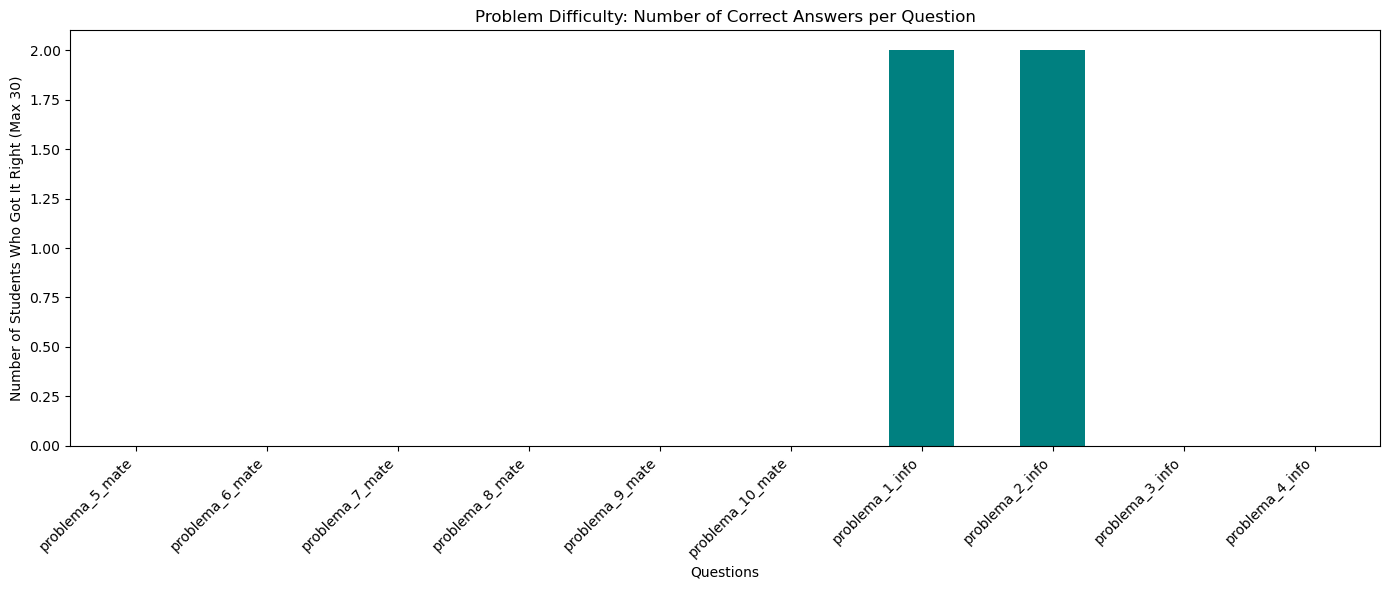

In [202]:
info_answers = final_df.iloc[:, 16:26] 
info_correct = info_answers == info_answer_key.values

info_problem_scores = info_correct.sum(axis=0)

plt.figure(figsize=(14, 6))

info_problem_scores.plot(kind='bar', color='teal')

plt.title('Problem Difficulty: Number of Correct Answers per Question')
plt.ylabel('Number of Students Who Got It Right (Max 30)')
plt.xlabel('Questions')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

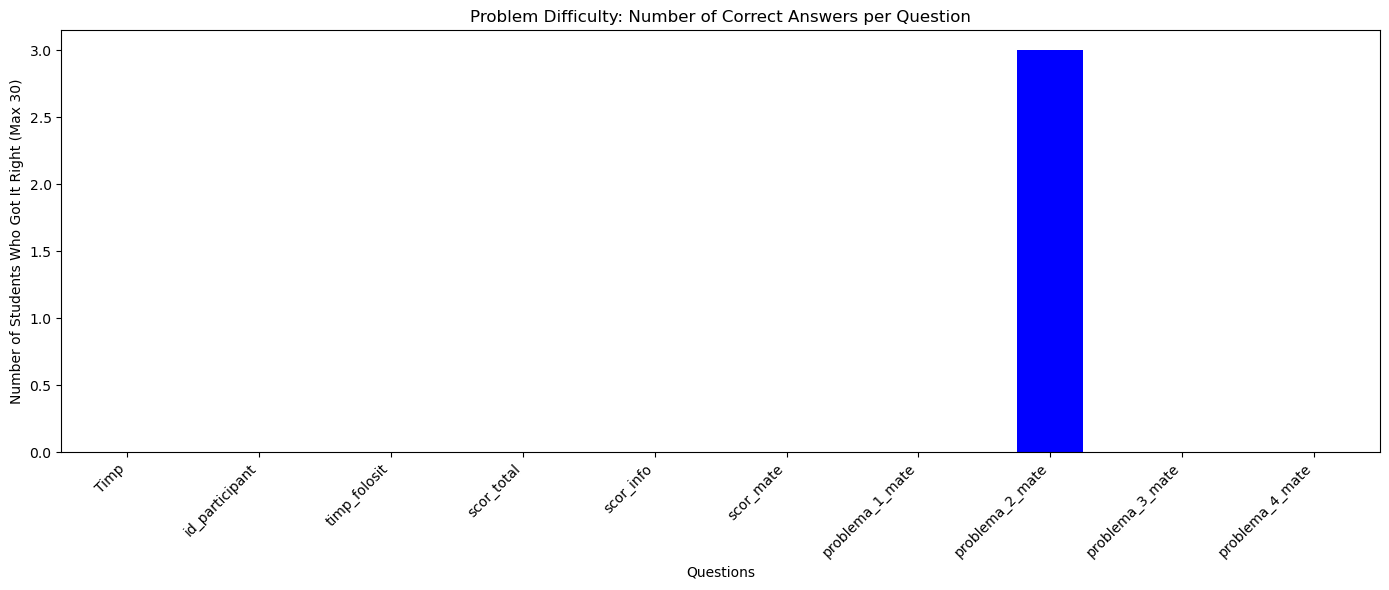

In [203]:
math_answers = final_df.iloc[:, 6:16] 
math_correct = math_answers == mate_answer_key.values

math_problem_scores = math_correct.sum(axis=0)

plt.figure(figsize=(14, 6))

math_problem_scores.plot(kind='bar', color='blue')

plt.title('Problem Difficulty: Number of Correct Answers per Question')
plt.ylabel('Number of Students Who Got It Right (Max 30)')
plt.xlabel('Questions')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

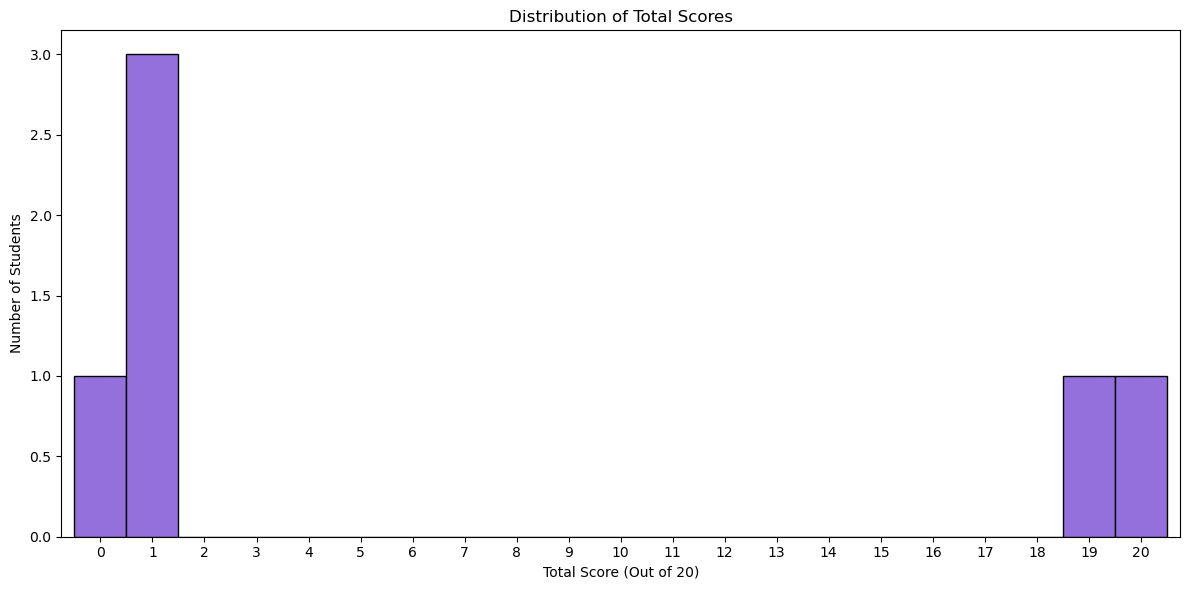

In [204]:

score_counts = final_df['scor_total'].value_counts()

all_possible_scores = range(0, 21) 
score_distribution = score_counts.reindex(all_possible_scores, fill_value=0)

plt.figure(figsize=(12, 6))

score_distribution.plot(kind='bar', color='mediumpurple', edgecolor='black', width=1.0)

plt.title('Distribution of Total Scores')
plt.xlabel('Total Score (Out of 20)')
plt.ylabel('Number of Students')

plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

In [205]:
final_barem

,Mate_Answers,Info_Answers
0,b,d
1,b,d
2,c,b
3,d,c
4,c,b
5,c,d
6,5,d
7,b,d
8,a,e
9,a,d
